## 📊 Análise de Desempenho do Brasileirão 

<small>Quais características estatísticas realmente diferenciam as posições na tabela
e o que torna um time campeão? Analisaremos o ataque, defesa e saldo de gols.</small>

------

##### 1. Análise Exploratória Simples

<small>Vamos compreender a estrutura geral dos dados.</small>

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df_base = pd.read_csv("../data/dataset.csv")
df_base

,season,place,team,points,played,won,draw,loss,goals,goals_taken,goals_diff
0,2003,1,Cruzeiro,100,46,31,7,8,102,47,55
1,2003,2,Santos,87,46,25,12,9,93,60,33
2,2003,3,São Paulo,78,46,22,12,12,81,67,14
3,2003,4,São Caetano,74,46,19,14,13,53,37,16
4,2003,5,Coritiba,73,46,21,10,15,67,58,9
...,...,...,...,...,...,...,...,...,...,...,...
465,2025,16,Internacional,44,38,11,11,16,44,57,-13
466,2025,17,Ceará,43,38,11,10,17,34,40,-6
467,2025,18,Fortaleza,43,38,11,10,17,43,58,-15
468,2025,19,Juventude,35,38,9,8,21,35,69,-34


In [6]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   season       470 non-null    int64 
 1   place        470 non-null    int64 
 2   team         470 non-null    object
 3   points       470 non-null    int64 
 4   played       470 non-null    int64 
 5   won          470 non-null    int64 
 6   draw         470 non-null    int64 
 7   loss         470 non-null    int64 
 8   goals        470 non-null    int64 
 9   goals_taken  470 non-null    int64 
 10  goals_diff   470 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 40.5+ KB


In [7]:
df_base.describe() # Visualizando estatísticas descritivas para entender a distribuição inicial

,season,place,points,played,won,draw,loss,goals,goals_taken,goals_diff
count,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000
mean,2013.782979,10.751064,53.282979,39.004255,14.351064,10.297872,14.355319,49.944681,49.957447,-0.012766
std,6.733404,5.961832,12.821670,2.507979,4.402721,2.605676,4.431344,12.749394,12.438775,16.873916
min,2003.000000,1.000000,15.000000,38.000000,1.000000,3.000000,3.000000,18.000000,19.000000,-57.000000
25%,2008.000000,6.000000,45.000000,38.000000,11.000000,8.000000,11.000000,41.000000,41.000000,-10.000000
50%,2014.000000,11.000000,53.000000,38.000000,14.000000,10.000000,14.000000,49.000000,48.000000,-1.000000
75%,2020.000000,16.000000,61.000000,38.000000,17.000000,12.000000,17.000000,58.000000,58.000000,11.000000
max,2025.000000,24.000000,100.000000,46.000000,31.000000,18.000000,29.000000,103.000000,92.000000,55.000000


In [8]:
df_base.isnull().sum() # Verificando se há valores nulos

season         0
place          0
team           0
points         0
played         0
won            0
draw           0
loss           0
goals          0
goals_taken    0
goals_diff     0
dtype: int64

In [9]:
"""
Nesta célula, estamos checando se não existe um número impossível de certas 
estatísticas. Elas não podem ser maiores do que o número de jogos.

OBS: No brasileirão, uma vitória é equivalente a três pontos.
"""

print((df_base["points"] > df_base["played"] * 3).any()) 
print((df_base["won"] > df_base["played"]).any())
print((df_base["draw"] > df_base["played"]).any())
print((df_base["loss"] > df_base["played"]).any())



False
False
False
False


In [10]:
# Checando quais temporadas existem

df_base["season"].unique()

array([2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025])

In [11]:
# Agora, vamos checar se todas as temporadas tiveram o mesmo número de partidas.


df_base["played"].unique()

array([46, 42, 38])

In [12]:
# Agora, analisaremos em quais temporadas foram jogados cada número de partidas.


df_base.groupby("season")["played"].max()

season
2003    46
2004    46
2005    42
2006    38
2007    38
2008    38
2009    38
2010    38
2011    38
2012    38
2013    38
2014    38
2015    38
2016    38
2017    38
2018    38
2019    38
2020    38
2021    38
2022    38
2023    38
2024    38
2025    38
Name: played, dtype: int64

----------

##### 2. Preparação de Dados

<small>Vamos preparar e tratar os dados.</small>

---------------

<small>Vimos que, em anos específicos, alguns clubes tiveram um maior número de partidas do que outros em temporadas diferentes. Isso permite que um time acumule mais estatísticas em comparação aos que tiveram menos oportunidades em outras temporadas.

Para que não hajam imprecisões nesse sentido, trabalharemos com um novo dataframe contendo somente as temporadas onde os times disputaram 38 partidas (2006-2025).
</small>

In [13]:
df_38_rodadas = df_base[df_base["played"] == 38].copy() # Criação do novo dataframe

In [14]:
# Crio algumas novas tabelas que serão úteis e também quebro os números em até 2 casas decimais.

df_38_rodadas["med_gols_jogo"] = (
    df_38_rodadas["goals"] / df_38_rodadas["played"] * 100).astype(int) / 100

df_38_rodadas["med_gols_sofridos_jogo"] = (
    df_38_rodadas["goals_taken"] / df_38_rodadas["played"] * 100).astype(int) / 100

In [15]:
# Separo os times em 3 grupos com base em suas colocações: Topo: 1-6, Meio: 7-14, Baixo: 15-20. 

df_38_rodadas["grupo"] = pd.cut(
    df_38_rodadas["place"],
    bins=[0, 6, 14, 20],
    labels=["Topo", "Meio", "Baixo"]
)

In [16]:
# Visualização do dataframe atualizado

df_38_rodadas

,season,place,team,points,played,won,draw,loss,goals,goals_taken,goals_diff,med_gols_jogo,med_gols_sofridos_jogo,grupo
70,2006,1,São Paulo,78,38,22,12,4,66,32,34,1.73,0.84,Topo
71,2006,2,Internacional,69,38,20,9,9,52,36,16,1.36,0.94,Topo
72,2006,3,Grêmio,67,38,20,7,11,64,45,19,1.68,1.18,Topo
73,2006,4,Santos,64,38,18,10,10,58,36,22,1.52,0.94,Topo
74,2006,5,Paraná,60,38,18,6,14,56,49,7,1.47,1.28,Topo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,2025,16,Internacional,44,38,11,11,16,44,57,-13,1.15,1.50,Baixo
466,2025,17,Ceará,43,38,11,10,17,34,40,-6,0.89,1.05,Baixo
467,2025,18,Fortaleza,43,38,11,10,17,43,58,-15,1.13,1.52,Baixo
468,2025,19,Juventude,35,38,9,8,21,35,69,-34,0.92,1.81,Baixo


------------
##### 3. Análises Gerais e Testes de Hipótese

<small>Agora, iniciaremos os testes de hipótese e tentaremos tirar algumas conclusões úteis dessas análises.</small>

**Hipótese 1**: Times do topo marcam significativamente mais gols do que os demais, e isso influencia diretamente na colocação.

In [17]:
df_38_rodadas.groupby("grupo", observed=True)["goals"].describe()

,count,mean,std,min,25%,50%,75%,max
grupo,,,,,,,,
Topo,120.0,56.958333,8.261886,38.0,52.00,57.5,61.25,86.0
Meio,160.0,46.306250,7.403039,27.0,41.00,45.5,51.00,67.0
Baixo,120.0,38.775000,8.457966,18.0,33.75,39.0,44.00,66.0


<Axes: title={'center': 'goals'}, xlabel='grupo'>

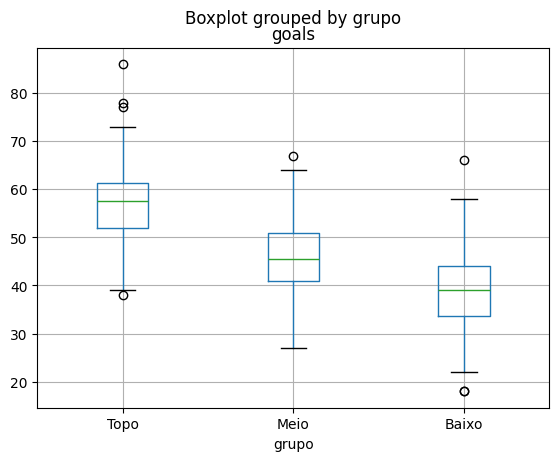

In [18]:
# Comparando a distribuição de gols marcados entre os grupos

df_38_rodadas.boxplot(column="goals", by="grupo")

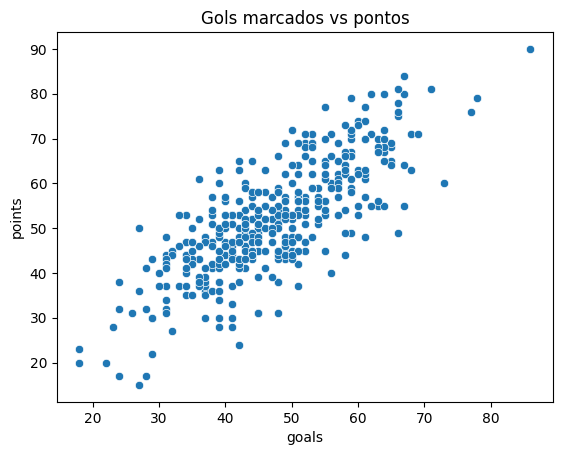

In [19]:
# Analisando relação entre gols marcados e pontuação final

sns.scatterplot(data=df_38_rodadas, x="goals", y="points")
plt.title("Gols marcados vs pontos")
plt.show()

<small>**Conclusão:** A análise foi baseada na comparação de métricas descritivas como média, mediana e quartis.

Os dados indicam que os times do topo apresentam maior média de gols marcados, o que sugere uma vantagem ofensiva em relação aos demais grupos.

No entanto, ao observar os quartis (25% e 75%), percebe-se que as distribuições dos grupos se aproximam, indicando sobreposição entre os níveis.

Além disso, a presença de valores extremos (mínimos e máximos) mostra que equipes fora do topo podem alcançar desempenhos ofensivos similares, ainda que com menor frequência.

Esses fatores indicam que, embora o ataque contribua para melhores posições, ele não é suficiente, isoladamente, para explicar a separação entre os grupos, apontando que outros fatores também podem desempenhar um papel relevante.</small>

------

**Hipótese 2:** A defesa tem maior influência na posição final do que o ataque.

In [20]:
df_38_rodadas.groupby("grupo", observed=True)[["goals", "goals_taken"]].describe()

goals                                                      goals_taken  \
       count       mean       std   min    25%   50%    75%   max       count   
grupo                                                                           
Topo   120.0  56.958333  8.261886  38.0  52.00  57.5  61.25  86.0       120.0   
Meio   160.0  46.306250  7.403039  27.0  41.00  45.5  51.00  67.0       160.0   
Baixo  120.0  38.775000  8.457966  18.0  33.75  39.0  44.00  66.0       120.0   

                                                             
            mean        std   min    25%   50%    75%   max  
grupo                                                        
Topo   39.208333   6.961956  19.0  34.75  39.0  44.00  58.0  
Meio   46.425000   7.343803  22.0  41.75  46.0  50.25  65.0  
Baixo  56.416667  10.059974  37.0  49.00  56.0  63.00  81.0

In [21]:
df_38_rodadas[["points", "goals", "goals_taken"]].corr()

,points,goals,goals_taken
points,1.000000,0.768481,-0.726052
goals,0.768481,1.000000,-0.248503
goals_taken,-0.726052,-0.248503,1.000000


In [22]:
df_38_rodadas[["place", "goals", "goals_taken"]].corr()

,place,goals,goals_taken
place,1.000000,-0.715888,0.697523
goals,-0.715888,1.000000,-0.248503
goals_taken,0.697523,-0.248503,1.000000


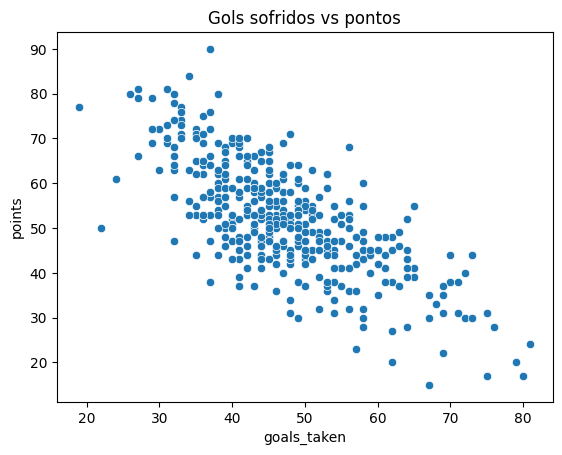

In [23]:
# Investigando impacto da defesa na pontuação

sns.scatterplot(data=df_38_rodadas, x="goals_taken", y="points")
plt.title("Gols sofridos vs pontos")
plt.show()

<small>**Conclusão:**

Os dados indicam que tanto o ataque quanto a defesa apresentam boa relação
com o desempenho das equipes, com leve vantagem para o ataque.

As diferenças entre os grupos são semelhantes em magnitude para ambas as métricas, e as correlações com pontos e posição são próximas.

Assim, não é possível afirmar que a defesa tenha maior influência que o ataque, mas sim que ambos desempenham papéis importantes no desempenho das equipes.</small>

--------

**Hipótese 3:** Saldo de gols como fator de separação.


In [24]:
df_38_rodadas.groupby("grupo", observed=True)["goals_diff"].describe()

,count,mean,std,min,25%,50%,75%,max
grupo,,,,,,,,
Topo,120.0,17.750000,10.303177,-2.0,10.75,17.0,24.0,51.0
Meio,160.0,-0.118750,7.257503,-18.0,-5.00,0.0,4.0,21.0
Baixo,120.0,-17.641667,11.558980,-57.0,-23.00,-17.0,-9.0,4.0


In [25]:
df_38_rodadas[["points", "goals_diff"]].corr()

,points,goals_diff
points,1.000000,0.945944
goals_diff,0.945944,1.000000


In [26]:
df_38_rodadas[["place", "goals_diff"]].corr()

,place,goals_diff
place,1.000000,-0.894516
goals_diff,-0.894516,1.000000


In [27]:
df_38_rodadas.groupby("grupo", observed=True)[["goals", "goals_taken", "goals_diff"]].mean()

,goals,goals_taken,goals_diff
grupo,,,
Topo,56.958333,39.208333,17.750000
Meio,46.306250,46.425000,-0.118750
Baixo,38.775000,56.416667,-17.641667


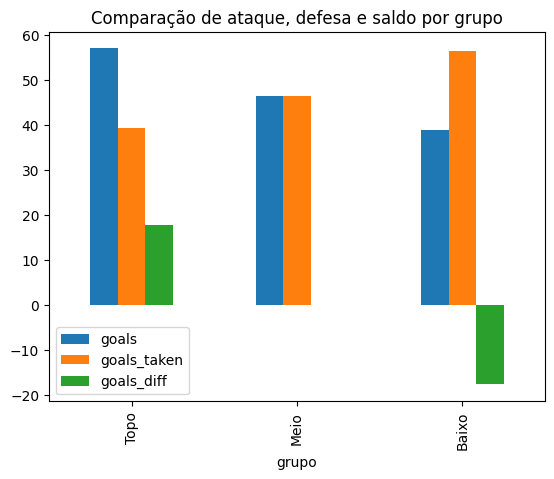

In [28]:
# Comparando médias de desempenho entre grupos (ataque, defesa e saldo de gols)

df_38_rodadas.groupby(
    "grupo", observed=True)[["goals", "goals_taken", "goals_diff"]].mean().plot(kind="bar")
plt.title("Comparação de ataque, defesa e saldo por grupo")
plt.show()

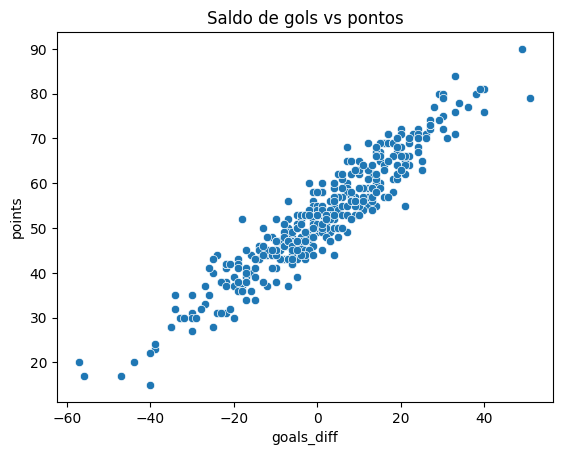

In [29]:
# Analisando relação entre saldo de gols e pontuação

sns.scatterplot(data=df_38_rodadas, x="goals_diff", y="points")
plt.title("Saldo de gols vs pontos")
plt.show()

<small>**Conclusão:**

O saldo de gols apresenta uma separação muito clara entre os grupos.

Times do topo possuem, em média, saldo positivo elevado, enquanto times do meio se concentram próximos de zero, e os da parte inferior apresentam saldo significativamente negativo.

Ao observar os quartis, percebe-se uma baixa sobreposição entre os grupos, indicando que essa métrica diferencia de forma mais consistente os níveis da tabela.

Além disso, o saldo de gols apresenta uma correlação muito forte com os pontos (0.94) e com a posição final (-0.89), sendo significativamente superior às correlações observadas para gols marcados e gols sofridos isoladamente.

Isso indica que o saldo de gols possui maior poder explicativo em relação ao desempenho das equipes. Ou seja, o desempenho no campeonato não é determinado apenas por ataque ou defesa isoladamente, mas pelo equilíbrio entre ambos, refletido no saldo de gols.